# 07 - Rate of climb: the symbolic (exact) approach with SymPy

This notebook mirrors notebook `03_RateOfClimb.ipynb`, but instead of evaluating
ready-made formulas it **derives** them with the computer-algebra system
[SymPy](https://www.sympy.org): equations of motion, optimum speeds, exact
steep-climb solutions, the acceleration factor, ceilings and time-to-climb
integrals.

References: Roskam & Lan, *Airplane Aerodynamics and Performance*, Chapter 9;
Anderson, *Aircraft Performance and Design*, Sections 5.10-5.12.

**How to use this notebook.** Run the cells in order (*Run -> Run All Cells*):
every symbol defined in a cell is used by the following ones. Each result is
compared with a textbook value by `check()`, which stops the notebook with an
error if the two disagree.

**SymPy best practices followed here** (from the official documentation,
*Explanation -> Best Practices* and *Guides -> Solving -> Solving Guidance*,
SymPy 1.14):

1. *Define symbols with* `symbols()` *and add the assumptions you know*
   (`positive=True`, `real=True`): SymPy can then choose the physical root of
   an equation and simplify square roots without `Piecewise` conditions.
2. *Use exact rational numbers, not floats* (`Rational(15, 1000)` or
   `Rational("0.015")` instead of `0.015`): the algebra stays exact and the
   numbers are rounded only once, at the very end, with `evalf()`.
3. *Use* `solve(expr, x, dict=True)` *and always name the unknown*, so the
   output format is predictable; use `Eq(lhs, rhs)` to write equations the way
   they appear in the book (it avoids sign errors).
4. *Avoid* `simplify()` *in programmatic code*; prefer targeted functions
   (`cancel`, `factor`, `expand`, `radsimp`, `powsimp`) whose output is
   predictable.
5. *Do not hard-code symbol names inside functions*: pass the symbols as
   arguments.
6. *When no closed form exists, go numeric explicitly*: `nsolve` for
   equations, `Integral(...).evalf()` for integrals.
7. *Separate symbolic and numeric code*: when many numerical evaluations
   are needed (plots), convert the final expression with `lambdify()` and
   use NumPy from there on. Never mix `math`/NumPy functions with SymPy
   expressions.

In [1]:
# --- Imports ---------------------------------------------------------------
import pathlib
import sys

import sympy as sp              # the symbolic engine: always used through the "sp." namespace
import numpy as np              # numeric arrays, used ONLY after lambdify (best practice 7)
import matplotlib.pyplot as plt
from IPython.display import Markdown, Math, display  # typeset output in the notebook

# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# The numerical package of this repository is used only to CROSS-CHECK the
# symbolic results (two independent implementations must agree).
from aircraft_performance import climb as num_climb           # noqa: E402
from aircraft_performance.aerodynamics import ParabolicDragPolar  # noqa: E402
from aircraft_performance.plotting import apply_style        # noqa: E402

apply_style()
print(f"SymPy version: {sp.__version__}")

SymPy version: 1.14.0


In [2]:
# --- Two small helpers used throughout the notebook ------------------------------
def show(title, expr):
    """Display a title and a SymPy object as typeset (LaTeX) mathematics.

    sp.latex() converts the expression to LaTeX, which Jupyter renders with
    MathJax; this is the notebook counterpart of sp.pprint().
    """
    display(Markdown(f"**{title}:**"), Math(sp.latex(expr)))


def check(label, computed, reference, rel_tol):
    """Compare a result with a textbook/reference value and STOP if they disagree.

    Raising an error (instead of printing a warning) guarantees that a wrong
    derivation can never go unnoticed: the notebook simply does not complete.
    """
    computed = float(computed)          # SymPy numbers -> Python float, only for the comparison
    reference = float(reference)
    rel = abs(computed - reference) / abs(reference)
    if rel > rel_tol:
        raise AssertionError(f"{label}: computed {computed:.6g}, reference {reference:.6g} "
                             f"(difference {100 * rel:.3f} % > {100 * rel_tol:.3f} %)")
    print(f"  [OK] {label}: {computed:.6g}  (reference {reference:.6g}, difference {100 * rel:.3f} %)")


def physical_root(solutions, unknown, sample):
    """Return the single solution of solve(..., dict=True) that is positive and real.

    SymPy keeps every root whose sign it *cannot disprove*: for example it cannot
    decide by itself that T - sqrt(T**2 + 12*CD0*K*W**2) is negative, so both
    roots of a quadratic in V**2 may survive the assumption ``positive=True``.
    We therefore test each candidate at a representative point ``sample``
    (a dict of positive parameter values) and keep the positive one. If the
    selection is ambiguous we stop, rather than silently taking the first root.
    """
    candidates = [sol[unknown] for sol in solutions]
    good = []
    for c in candidates:
        value = sp.N(c.subs(sample), 30)
        if value.is_real and value > 0:
            good.append(c)
    if len(good) != 1:
        raise ValueError(f"Expected one physical root, found {len(good)} among {candidates}")
    return good[0]


def is_identically_zero(expr):
    """Targeted check that an expression involving square roots of positive symbols is zero.

    1. expand + powdenest(force=True) splits sqrt(a*b) into sqrt(a)*sqrt(b)
       (legitimate here because all the symbols are declared positive);
    2. factor() collects the result. If this is not conclusive, fall back on
       Expr.equals(0), which SymPy documents as a combined symbolic/numeric test.
    """
    reduced = sp.factor(sp.powdenest(sp.expand(expr), force=True))
    return reduced == 0 or bool(reduced.equals(0))


# A representative set of positive values used ONLY to pick physical roots
SAMPLE = {}

## 1. Symbols and the equations of motion

Along and normal to a straight flight path inclined by $\gamma$, with the
thrust aligned with the velocity and no acceleration (Roskam Eqns 9.3-9.4):

$$T - D - W\sin\gamma = 0,\qquad L - W\cos\gamma = 0 .$$

All the physical quantities below are strictly positive, and we say so to
SymPy (best practice 1). The flight-path angle is only known to be real.

In [3]:
# Physical parameters (all positive) -------------------------------------------
W, S, rho = sp.symbols("W S rho", positive=True)            # weight, wing area, density
CD0, K = sp.symbols("C_D0 K", positive=True)                # parabolic polar CD = CD0 + K CL^2
T, P = sp.symbols("T P", positive=True)                     # thrust (jet), thrust power (propeller)
V, CL = sp.symbols("V C_L", positive=True)                  # true airspeed, lift coefficient
q = sp.Symbol("q", positive=True)                           # dynamic pressure
# Kinematic unknowns ------------------------------------------------------------
gamma = sp.Symbol("gamma", real=True)                       # flight-path angle (can be negative)
L_, D_ = sp.symbols("L D", positive=True)                    # lift and drag as generic forces

SAMPLE.update({W: 100000, S: 50, rho: sp.Rational(1), CD0: sp.Rational(2, 100), K: sp.Rational(5, 100),
               T: 20000, P: 2000000})

# The two equilibrium equations, written with Eq() exactly as in the book
eq_path = sp.Eq(T - D_ - W * sp.sin(gamma), 0)      # along the flight path
eq_normal = sp.Eq(L_ - W * sp.cos(gamma), 0)        # normal to the flight path
show("Equilibrium along the path", eq_path)
show("Equilibrium normal to the path", eq_normal)

# Solve the first equation for sin(gamma): this is the CLIMB GRADIENT.
# We name the unknown explicitly and ask for a list of dicts (best practice 3).
s = sp.Symbol("s", real=True)                                # s = sin(gamma)
climb_gradient = sp.solve(eq_path.subs(sp.sin(gamma), s), s, dict=True)[0][s]
show("Climb gradient  sin(gamma) = ", climb_gradient)

# The rate of climb is the vertical component of the velocity, RC = V sin(gamma)
RC_general = V * climb_gradient
show("Rate of climb  RC = V sin(gamma) = ", RC_general)

**Equilibrium along the path:**

<IPython.core.display.Math object>

**Equilibrium normal to the path:**

<IPython.core.display.Math object>

**Climb gradient  sin(gamma) = :**

<IPython.core.display.Math object>

**Rate of climb  RC = V sin(gamma) = :**

<IPython.core.display.Math object>

**Small-angle approximation** (Roskam Eqns 9.5-9.7): for $\gamma\lesssim15°$,
$\cos\gamma\approx1$ and the lift equals the weight. The drag of a parabolic
polar is then written in terms of the speed only:

$$D(V) = \tfrac12\rho V^2 S C_{D_0} + \frac{K W^2}{\tfrac12\rho V^2 S}.$$

In [4]:
# Level-flight lift coefficient CL = W / (q S) and the dynamic pressure q = rho V^2 / 2
q_of_V = rho * V**2 / 2
CL_level = W / (q_of_V * S)
drag_of_V = q_of_V * S * (CD0 + K * CL_level**2)   # parabolic polar
drag_of_V = sp.expand(drag_of_V)                    # targeted simplification: split into D0 + Di
show("Drag in (quasi-)level flight D(V)", drag_of_V)

**Drag in (quasi-)level flight D(V):**

<IPython.core.display.Math object>

## 2. Jet aircraft (constant thrust)

### 2.1 Maximum rate of climb

$RC(V) = [T - D(V)]\,V/W$. The optimum speed follows from
$\partial RC/\partial V = 0$. Because the drag only contains $V^2$ and
$V^{-2}$, the equation is a quadratic in $x = V^2$: we substitute
$V=\sqrt{x}$ to let `solve` return the root in closed form, and the
assumption `x > 0` automatically discards the negative (non-physical) root.

In [5]:
RC_jet = (T - drag_of_V) * V / W                       # rate of climb as a function of V
dRC_dV = sp.diff(RC_jet, V)                            # derivative with respect to the speed
show("dRC/dV", dRC_dV)

x = sp.Symbol("x", positive=True)                      # x = V^2
condition = sp.numer(sp.together(dRC_dV.subs(V, sp.sqrt(x))))   # numerator of the derivative = 0
V2_solutions = sp.solve(condition, x, dict=True)       # list of dicts, one per solution
print(f"\nsolve() returned {len(V2_solutions)} candidate(s) for V^2 (x was declared positive):")
for sol in V2_solutions:
    display(Math(sp.latex(sol[x])))
# One of them, T - sqrt(T^2 + 12 CD0 K W^2), is actually negative, but SymPy
# cannot prove it from the assumptions alone: we select the physical root.
V2_best = physical_root(V2_solutions, x, SAMPLE)
show("V^2 for maximum RC (jet)", V2_best)

**dRC/dV:**

<IPython.core.display.Math object>


solve() returned 2 candidate(s) for V^2 (x was declared positive):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

**V^2 for maximum RC (jet):**

<IPython.core.display.Math object>

This is Anderson's Eqn (5.112):
$V^2 = \dfrac{T/S + \sqrt{(T/S)^2 + 12 C_{D_0} K (W/S)^2}}{3\rho C_{D_0}}$
(in the form above, multiply numerator and denominator by $S$).

Roskam writes the same optimum in terms of the lift coefficient (Eqn 9.30):
$C_L = -\frac{T}{W}\frac{\pi Ae}{2} + \sqrt{\left(\frac{T}{W}\frac{\pi Ae}{2}\right)^2 + 3C_{D_0}\pi Ae}$
with $\pi Ae = 1/K$. We prove symbolically that the two are identical:
the difference is rationalised with `radsimp` (a *targeted* simplification
for radicals in denominators) and must reduce to exactly zero.

In [6]:
CL_best_from_V = sp.radsimp(2 * W / (rho * V2_best * S))          # CL = 2W/(rho V^2 S)
piAe = 1 / K
CL_best_roskam = -(T / W) * piAe / 2 + sp.sqrt(((T / W) * piAe / 2)**2 + 3 * CD0 * piAe)
show("CL for max RC derived here", CL_best_from_V)
show("CL from Roskam Eqn 9.30", CL_best_roskam)
if not is_identically_zero(CL_best_from_V - CL_best_roskam):
    raise AssertionError("Roskam Eqn 9.30 not reproduced")
print("  -> the difference reduces to exactly zero: the two formulas are the same.")

# Maximum rate of climb: substitute the optimum V back into RC(V)
RC_jet_max = RC_jet.subs(V, sp.sqrt(V2_best))
show("RC_max (jet), closed form", RC_jet_max)

**CL for max RC derived here:**

<IPython.core.display.Math object>

**CL from Roskam Eqn 9.30:**

<IPython.core.display.Math object>

  -> the difference reduces to exactly zero: the two formulas are the same.


**RC_max (jet), closed form:**

<IPython.core.display.Math object>

### 2.2 Numerical example: Anderson's Gulfstream IV (Example 5.13 and 5.16)

Anderson's data are in British units: $W = 73{,}000$ lb, $S = 950$ ft²,
$C_D = 0.015 + 0.08\,C_L^2$, $T = 2\times13{,}850$ lb at sea level. The
formulas are dimensionally consistent, so we can use the book's units
directly (slug/ft³ for density, ft/s for speeds). All data are entered as
exact rationals (best practice 2) and the result is rounded once with
`evalf(subs=...)`, which substitutes and evaluates in a single, accurate step.

In [7]:
anderson = {
    W: 73000,                              # lb
    S: 950,                                # ft^2
    CD0: sp.Rational("0.015"),
    K: sp.Rational("0.08"),
    T: 2 * 13850,                          # lb
    rho: sp.Rational("0.002377"),          # slug/ft^3, sea level
}
RC_SL = RC_jet_max.evalf(8, subs=anderson)
V_SL = sp.sqrt(V2_best).evalf(8, subs=anderson)
print(f"Sea level: RC_max = {RC_SL} ft/s at V = {V_SL} ft/s")
check("RC_max at sea level [ft/s] vs Anderson Example 5.16", RC_SL, 179.9, 2e-3)

Sea level: RC_max = 179.82064 ft/s at V = 747.32330 ft/s
  [OK] RC_max at sea level [ft/s] vs Anderson Example 5.16: 179.821  (reference 179.9, difference 0.044 %)


### 2.3 Steepest climb (small angles)

With constant thrust, $\sin\gamma = (T-D)/W$ is maximum where the drag is
minimum. We minimise $D(V)$ and substitute back.

In [8]:
V2_min_drag = physical_root(
    sp.solve(sp.numer(sp.together(sp.diff(drag_of_V, V).subs(V, sp.sqrt(x)))), x, dict=True), x, SAMPLE)
show("V^2 for minimum drag (point E)", V2_min_drag)
D_min = sp.factor(drag_of_V.subs(V, sp.sqrt(V2_min_drag)))
show("Minimum drag D_min", D_min)
E_max = sp.radsimp(W / D_min)
show("E_max = W / D_min", E_max)
sin_gamma_max = sp.expand(T / W - D_min / W)
show("sin(gamma_max) = T/W - 1/E_max  (Roskam Eqn 9.32)", sin_gamma_max)

gamma_max_deg = sp.deg(sp.asin(sin_gamma_max)).evalf(8, subs=anderson)
check("gamma_max at sea level [deg] vs Anderson Example 5.13", gamma_max_deg, 18.07, 2e-3)

**V^2 for minimum drag (point E):**

<IPython.core.display.Math object>

**Minimum drag D_min:**

<IPython.core.display.Math object>

**E_max = W / D_min:**

<IPython.core.display.Math object>

**sin(gamma_max) = T/W - 1/E_max  (Roskam Eqn 9.32):**

<IPython.core.display.Math object>

  [OK] gamma_max at sea level [deg] vs Anderson Example 5.13: 18.0695  (reference 18.07, difference 0.003 %)


### 2.4 Steep climb, exact solution (Roskam Sec. 9.2.2)

Without small-angle approximations, $L = W\cos\gamma$, hence
$C_L = W\cos\gamma/(qS)$ and the equation along the path becomes

$$T - qSC_{D_0} - \frac{KW^2\cos^2\gamma}{qS} - W\sin\gamma = 0 .$$

Writing $\cos^2\gamma = 1-\sin^2\gamma$ gives a **quadratic** in
$s=\sin\gamma$, which SymPy solves exactly. Of the two roots only one is
physical (the one with $|s|\le1$ that reduces to the small-angle result);
we select it by checking the conditions, not by assuming its position in
the list.

In [9]:
steep_equation = sp.Eq(T - q * S * CD0 - K * W**2 * (1 - s**2) / (q * S) - W * s, 0)
show("Exact steep-climb equation in s = sin(gamma)", steep_equation)
roots = [sol[s] for sol in sp.solve(steep_equation, s, dict=True)]
for i, r in enumerate(roots):
    show(f"Root {i}", r)

# A demanding case: a light jet trainer with T/W = 0.5 (Anderson-like numbers, SI units)
trainer = {W: 50000, S: 20, CD0: sp.Rational("0.02"), K: sp.Rational("0.06"),
           T: 25000, rho: sp.Rational("1.225")}
V_test = 120                                   # m/s
q_test = (trainer[rho] * V_test**2 / 2)
rows = []
for r in roots:
    val = r.evalf(12, subs={**trainer, q: q_test})
    physical = val.is_real and abs(val) <= 1
    rows.append((val, physical))
    print(f"  root = {val}   physical: {physical}")
s_exact = [v for v, ok in rows if ok]
if len(s_exact) != 1:
    raise AssertionError("Expected exactly one physical root for the steep-climb equation.")
s_exact = s_exact[0]
s_small = climb_gradient.subs(D_, drag_of_V).evalf(12, subs={**trainer, V: V_test})
print(f"\nAt V = {V_test} m/s: gamma exact = {sp.deg(sp.asin(s_exact)).evalf(5)} deg, "
      f"small-angle = {sp.deg(sp.asin(s_small)).evalf(5)} deg")

# Cross-check with the numerical package (independent root finder)
from aircraft_performance.aircraft import Aircraft, Configuration   # noqa: E402
from aircraft_performance.propulsion import JetPropulsion            # noqa: E402
trainer_ac = Aircraft("trainer", mass=50000 / 9.80665, wing_area=20.0, wing_span=12.0,
                      configurations={"clean": Configuration(ParabolicDragPolar(0.02, 0.06), 1.5)},
                      propulsion=JetPropulsion(25000.0, 1e-4, n_engines=1, lapse_exponent=1.0))
check("exact steep-climb angle vs aircraft_performance.climb.steep_climb [deg]",
      sp.deg(sp.asin(s_exact)).evalf(), num_climb.steep_climb(trainer_ac, V_test, 0.0).gamma_deg, 1e-6)

**Exact steep-climb equation in s = sin(gamma):**

<IPython.core.display.Math object>

**Root 0:**

<IPython.core.display.Math object>

**Root 1:**

<IPython.core.display.Math object>

  root = 0.415367382007   physical: True
  root = 58.3846326180   physical: False

At V = 120 m/s: gamma exact = 24.542 deg, small-angle = 24.358 deg
  [OK] exact steep-climb angle vs aircraft_performance.climb.steep_climb [deg]: 24.5425  (reference 24.5425, difference 0.000 %)


## 3. Propeller aircraft (constant power)

### 3.1 Maximum rate of climb

With the thrust power $P = \eta_p P_{shaft}$ independent of speed,
$RC = [P - D(V)V]/W$. The optimum is at minimum power required.

In [10]:
RC_prop = (P - drag_of_V * V) / W
V2_best_prop = physical_root(
    sp.solve(sp.numer(sp.together(sp.diff(RC_prop, V).subs(V, sp.sqrt(x)))), x, dict=True), x, SAMPLE)
show("V^2 for maximum RC (propeller)", V2_best_prop)
CL_best_prop = sp.powsimp(sp.radsimp(2 * W / (rho * V2_best_prop * S)), force=True)
show("CL for maximum RC (propeller)  -> sqrt(3 CD0 / K), Roskam Eqn 9.57", CL_best_prop)
if not is_identically_zero(CL_best_prop**2 - 3 * CD0 / K):
    raise AssertionError("Roskam Eqn 9.57 not reproduced")

# The ratio between the jet-type optimum (minimum drag, point E) and the
# propeller optimum (minimum power, point P): an exact number, 3^(1/4)
ratio = sp.powsimp(sp.sqrt(sp.cancel(V2_min_drag / V2_best_prop)), force=True)
show("V_E / V_P (Roskam Eqn 8.75)", ratio)

RC_prop_max = sp.radsimp(RC_prop.subs(V, sp.sqrt(V2_best_prop)))
show("RC_max (propeller), closed form", RC_prop_max)

**V^2 for maximum RC (propeller):**

<IPython.core.display.Math object>

**CL for maximum RC (propeller)  -> sqrt(3 CD0 / K), Roskam Eqn 9.57:**

<IPython.core.display.Math object>

**V_E / V_P (Roskam Eqn 8.75):**

<IPython.core.display.Math object>

**RC_max (propeller), closed form:**

<IPython.core.display.Math object>

### 3.2 Roskam Example 9.2 (twin turboprop)

$W = 36{,}000$ lb, $S = 450$ ft², $C_D = 0.0200 + 0.05C_L^2$. The installed
power is the one that gives 400 kt at sea level, with a compressibility
increment $\Delta C_D = 0.0015$ at that speed. Everything in British units,
as in the book.

In [11]:
KT_FPS = sp.Rational(6076115, 3600000)        # 1 knot in ft/s, exact (1 nm = 6076.115 ft)
roskam92 = {W: 36000, S: 450, CD0: sp.Rational("0.02"), K: sp.Rational("0.05"), rho: sp.Rational("0.002377")}
V_max = 400 * KT_FPS
# Power needed at V_max: THP = D V with the extra compressibility drag
P_avail = (drag_of_V * V + sp.Rational("0.0015") * q_of_V * S * V).subs(V, V_max).subs(roskam92)
print(f"THP available = {sp.N(P_avail / 550, 6)} hp  (Roskam: 6,768 hp)")
RC92 = RC_prop_max.subs(roskam92).subs(P, P_avail)
V92 = sp.sqrt(V2_best_prop).subs(roskam92)
check("Roskam Ex. 9.2 RC_max [ft/min]", RC92.evalf() * 60, 5116, 2e-3)
check("Roskam Ex. 9.2 best-RC speed [kt]", (V92 / KT_FPS).evalf(), 147, 5e-3)

THP available = 6759.66 hp  (Roskam: 6,768 hp)
  [OK] Roskam Ex. 9.2 RC_max [ft/min]: 5110.18  (reference 5116, difference 0.114 %)
  [OK] Roskam Ex. 9.2 best-RC speed [kt]: 146.868  (reference 147, difference 0.090 %)


### 3.3 Steep climb of the propeller aircraft (Roskam Eqns 9.61-9.64)

Roskam keeps the lift-to-drag ratio of the best-RC point and writes
$\dfrac{C_L}{C_D} = \dfrac{W\cos\gamma}{T - W\sin\gamma}$ with $T = P/V$.
Squaring to remove $\cos\gamma = \sqrt{1-\sin^2\gamma}$ gives a quadratic in
$\sin\gamma$ (Eqn 9.63). **Squaring introduces a spurious root**: we keep
only the root that satisfies the *original*, unsquared equation - which is
why Roskam says "the minus sign is required".

In [12]:
E_ratio = sp.Symbol("E", positive=True)                     # CL/CD at the operating point
xw = sp.Symbol("x_w", positive=True)                        # x_w = T / W = P / (W V)
unsquared = sp.Eq(E_ratio * (xw - s), sp.sqrt(1 - s**2))     # (L/D)(T/W - sin g) = cos g
squared = sp.Eq(E_ratio**2 * (xw - s)**2, 1 - s**2)
candidates = [sol[s] for sol in sp.solve(squared, s, dict=True)]
CL92 = CL_best_prop.subs(roskam92)
CD92 = (CD0 + K * CL92**2).subs(roskam92)
vals92 = {E_ratio: CL92 / CD92, xw: P_avail / (roskam92[W] * V92)}
valid = []
for c in candidates:
    lhs = unsquared.lhs.subs(s, c).evalf(30, subs=vals92)
    rhs = unsquared.rhs.subs(s, c).evalf(30, subs=vals92)
    ok = abs(lhs - rhs) < 1e-20
    print(f"  candidate sin(gamma) = {c.evalf(8, subs=vals92)}  satisfies the unsquared equation: {ok}")
    if ok:
        valid.append(c)
if len(valid) != 1:
    raise AssertionError("The steep-climb equation should have exactly one valid root.")
gamma92 = sp.deg(sp.asin(valid[0])).evalf(6, subs=vals92)
check("Roskam Ex. 9.2 exact climb angle [deg] (Eqn 9.64)", gamma92, 20.4, 3e-3)

  candidate sin(gamma) = 0.34815435  satisfies the unsquared equation: True
  candidate sin(gamma) = 0.48065551  satisfies the unsquared equation: False
  [OK] Roskam Ex. 9.2 exact climb angle [deg] (Eqn 9.64): 20.3745  (reference 20.4, difference 0.125 %)


## 4. The acceleration factor, derived (Roskam Sec. 9.5)

In an accelerated climb $RC = RC_{steady}/(1 + \frac{V}{g}\frac{dV}{dh})$.
In the troposphere $T = T_0 - Lh$ and
$\sigma = (T/T_0)^{g/(LR)-1}$ (Capitolo1 notebook). We let SymPy derive the
acceleration factor for the two classic speed schedules and express it in
terms of the Mach number $M^2 = V^2/(\gamma_a R T)$.

In [13]:
h = sp.Symbol("h", nonnegative=True)                          # geopotential altitude [m]
g0, Rgas, Lapse, T0, gam_a = sp.symbols("g_0 R L_T T_0 gamma_a", positive=True)
Ve, Mach = sp.symbols("V_e M", positive=True)

Temp = T0 - Lapse * h                                         # temperature in the troposphere
sigma_tropo = (Temp / T0)**(g0 / (Lapse * Rgas) - 1)          # density ratio (exact, symbolic)

# (a) constant equivalent airspeed: V = Ve / sqrt(sigma)
V_eas_schedule = Ve / sp.sqrt(sigma_tropo)
f_eas = V_eas_schedule / g0 * sp.diff(V_eas_schedule, h)
f_eas_over_M2 = sp.cancel(sp.powsimp(f_eas / (V_eas_schedule**2 / (gam_a * Rgas * Temp)), force=True))
show("Constant EAS: (V/g dV/dh) / M^2", f_eas_over_M2)

# (b) constant Mach number: V = M sqrt(gamma R T)
V_mach_schedule = Mach * sp.sqrt(gam_a * Rgas * Temp)
f_mach = sp.cancel(V_mach_schedule / g0 * sp.diff(V_mach_schedule, h))
show("Constant Mach: V/g dV/dh", f_mach)

# Exact ISA constants (best practice 2: rationals, not floats)
isa_constants = {g0: sp.Rational("9.80665"), Rgas: sp.Rational("287.05287"),
                 Lapse: sp.Rational("0.0065"), T0: sp.Rational("288.15"), gam_a: sp.Rational(7, 5)}
coef_eas = f_eas_over_M2.subs(isa_constants)
coef_mach = sp.cancel(f_mach / Mach**2).subs(isa_constants)
print(f"\nConstant EAS : factor = {sp.N(coef_eas, 6)} M^2   (Roskam Eqn 9.84: 0.567 M^2)")
print(f"Constant Mach: factor = {sp.N(coef_mach, 6)} M^2  (Roskam Eqn 9.87: -0.133 M^2)")
check("acceleration factor coefficient, constant EAS", coef_eas, 0.567, 1e-3)
check("acceleration factor coefficient, constant Mach", coef_mach, -0.133, 2e-3)

**Constant EAS: (V/g dV/dh) / M^2:**

<IPython.core.display.Math object>

**Constant Mach: V/g dV/dh:**

<IPython.core.display.Math object>


Constant EAS : factor = 0.566816 M^2   (Roskam Eqn 9.84: 0.567 M^2)
Constant Mach: factor = -0.133184 M^2  (Roskam Eqn 9.87: -0.133 M^2)
  [OK] acceleration factor coefficient, constant EAS: 0.566816  (reference 0.567, difference 0.032 %)
  [OK] acceleration factor coefficient, constant Mach: -0.133184  (reference -0.133, difference 0.138 %)


## 5. Ceilings in closed form

### 5.1 A symbolic standard atmosphere

To go from a density ratio to an altitude we need the inverse of the ISA.
The three ISA layers used by the numerical package all have exact inverses:

* troposphere (0-11 km): $h = \frac{T_0}{L}\left(1-\sigma^{1/n}\right)$ with $n = g/(LR)-1$;
* isothermal layer (11-20 km):
  $h = 11\,000 + \frac{RT_{11}}{g}\ln\frac{\sigma_{11}}{\sigma}$;
* stratosphere (20-32 km, $T = T_{11} + L_2(h-20\,000)$ with $L_2 = +1$ K/km):
  $\sigma = \sigma_{20}\left(T/T_{11}\right)^{-(g/(L_2R)+1)}$.

The functions receive the symbols/values they need as arguments
(best practice 5: no hard-coded symbols inside functions).

In [14]:
ISA = {key: isa_constants[key] for key in isa_constants}       # exact constants (SI)
# Why Floats here? n = g/(L R) - 1 is an exact fraction with ~20-digit numerator
# and denominator. Raising a Rational to such a power makes SymPy attempt an
# *exact* root extraction of huge integers, which can take minutes. The best
# practice "prefer exact numbers" applies when the exact form is usable; here a
# 30-significant-digit Float is far more accurate than any engineering need and
# keeps every evaluation instantaneous.
DIGITS = 30
N_EXP = sp.Float(ISA[g0] / (ISA[Lapse] * ISA[Rgas]) - 1, DIGITS)   # exponent n of the troposphere
T11 = ISA[T0] - ISA[Lapse] * 11000                             # 216.65 K (exact)
SIGMA11 = sp.Float(T11 / ISA[T0], DIGITS)**N_EXP               # density ratio at 11 km


LAPSE_20 = sp.Rational(1, 1000)                                # +1 K/km above 20 km
N_EXP_20 = sp.Float(ISA[g0] / (LAPSE_20 * ISA[Rgas]) + 1, DIGITS)   # exponent of the 20-32 km layer
SIGMA20 = SIGMA11 * sp.exp(sp.Float(-ISA[g0] * 9000 / (ISA[Rgas] * T11), DIGITS))   # density ratio at 20 km


def sigma_isa(altitude):
    """Exact ISA density ratio as a SymPy expression of a symbol or a number (0-32 km)."""
    tropo = (1 - ISA[Lapse] * altitude / ISA[T0])**N_EXP
    isothermal = SIGMA11 * sp.exp(-ISA[g0] * (altitude - 11000) / (ISA[Rgas] * T11))
    strato = SIGMA20 * ((T11 + LAPSE_20 * (altitude - 20000)) / T11)**(-N_EXP_20)
    return sp.Piecewise((tropo, altitude <= 11000), (isothermal, altitude <= 20000), (strato, True))


def altitude_from_sigma(sigma_value):
    """Exact inverse of sigma_isa for a *numerical* density ratio (returns metres, 0-32 km).

    The layer is chosen by comparing sigma with its values at 11 and 20 km; in
    each layer the inverse is an explicit formula (no root finding needed).
    """
    if sp.N(sigma_value) >= sp.N(SIGMA11):
        return ISA[T0] / ISA[Lapse] * (1 - sigma_value**(1 / N_EXP))
    if sp.N(sigma_value) >= sp.N(SIGMA20):
        return 11000 + ISA[Rgas] * T11 / ISA[g0] * sp.log(SIGMA11 / sigma_value)
    return 20000 + T11 / LAPSE_20 * ((sigma_value / SIGMA20)**(-1 / N_EXP_20) - 1)


print(f"n = g/(L R) - 1 = {sp.N(N_EXP, 6)},  sigma(11 km) = {sp.N(SIGMA11, 6)}")
for z in (5000, 15000, 25000):   # the inverse must return the altitude we started from, in every layer
    check(f"round trip altitude -> sigma -> altitude at {z} m", altitude_from_sigma(sigma_isa(z)).evalf(DIGITS), z, 1e-20)

n = g/(L R) - 1 = 4.25588,  sigma(11 km) = 0.297076
  [OK] round trip altitude -> sigma -> altitude at 5000 m: 5000  (reference 5000, difference 0.000 %)
  [OK] round trip altitude -> sigma -> altitude at 15000 m: 15000  (reference 15000, difference 0.000 %)
  [OK] round trip altitude -> sigma -> altitude at 25000 m: 25000  (reference 25000, difference 0.000 %)


### 5.2 Jet: absolute ceiling

With $T = T_{SL}\,\sigma^m$ and a parabolic polar, the maximum rate of climb
vanishes when the available thrust equals the minimum drag,
$T_{SL}\sigma^m = W/E_{max}$:

$$\sigma_{abs} = \left(\frac{W}{E_{max}\,T_{SL}}\right)^{1/m} .$$

In [15]:
sig, m_exp, T_SL = sp.symbols("sigma m T_SL", positive=True)
sigma_abs_jet = sp.solve(sp.Eq(T_SL * sig**m_exp, W / E_max), sig, dict=True)[0][sig]
show("sigma at the absolute ceiling (jet)", sigma_abs_jet)

giv = {W: 73000, T_SL: 27700, CD0: sp.Rational("0.015"), K: sp.Rational("0.08"), m_exp: sp.Rational("0.6")}
sigma_c = sigma_abs_jet.subs(giv)
h_abs_giv = altitude_from_sigma(sigma_c)
print(f"Gulfstream IV-like: sigma_abs = {sp.N(sigma_c, 6)}, absolute ceiling = {sp.N(h_abs_giv, 6)} m")
from aircraft_performance import examples  # noqa: E402
import warnings                              # noqa: E402
with warnings.catch_warnings():              # the numerical model warns about Mach > M_DD here (see notebook 03)
    warnings.simplefilter("ignore")
    h_abs_num = num_climb.ceilings(examples.business_jet_giv()).absolute
check("jet absolute ceiling vs numerical package [m]", h_abs_giv.evalf(), h_abs_num, 2e-4)

**sigma at the absolute ceiling (jet):**

<IPython.core.display.Math object>

Gulfstream IV-like: sigma_abs = 0.0587633, absolute ceiling = 21243.6 m


  [OK] jet absolute ceiling vs numerical package [m]: 21243.6  (reference 21243.6, difference 0.000 %)


### 5.3 Propeller: absolute ceiling (the Capitolo8 aircraft)

The `Capitolo8/RateoDiSalitaMotoelica` notebook uses $P = \eta_pP_0\sigma$ and
evaluates the climb at point P of the polar. The minimum power required
grows as $1/\sqrt\sigma$ (same $C_L$, speed $\propto 1/\sqrt\sigma$), so the
absolute ceiling satisfies

$$\eta_p P_0\,\sigma = \frac{P_{req,min,SL}}{\sqrt\sigma}
\;\Rightarrow\; \sigma_{abs} = \left(\frac{P_{req,min,SL}}{\eta_pP_0}\right)^{2/3}$$

With the Gagg-Ferrar law $P/P_0 = 1.132\sigma - 0.132$ (piston engines) the
condition becomes a **cubic** in $\sqrt\sigma$, which SymPy also solves.

In [16]:
eta, P0 = sp.symbols("eta_p P_0", positive=True)
P_req_min_SL = (drag_of_V * V).subs(V, sp.sqrt(V2_best_prop)).subs(rho, sp.Rational("1.225"))
cap8 = {W: 1338 * ISA[g0], S: sp.Rational("16.16"), CD0: sp.Rational("0.028"),
        K: 1 / (sp.pi * sp.Rational("10.90")**2 / sp.Rational("16.16") * sp.Rational("0.8")),
        eta: sp.Rational("0.8"), P0: 230 * sp.Rational("0.75") * 1000}

# (a) linear lapse P = P0 sigma
sigma_abs_lin = sp.solve(sp.Eq(eta * P0 * sig, P_req_min_SL / sp.sqrt(sig)), sig, dict=True)[0][sig]
show("sigma_abs, lapse P0*sigma", sigma_abs_lin)
h_lin = altitude_from_sigma(sigma_abs_lin.subs(cap8).evalf(30))
RC_SL_cap8 = ((eta * P0 - P_req_min_SL) / W).subs(cap8)
check("Capitolo8 RC at point P, sea level [m/s]", RC_SL_cap8.evalf(), 7.5850, 1e-3)
print(f"Absolute ceiling, P = P0 sigma: {sp.N(h_lin, 6)} m  (Capitolo8: RC < 0 between 8,000 and 9,000 m)")

# (b) Gagg-Ferrar lapse: eta P0 (1.132 sigma - 0.132) = P_req_min_SL / sqrt(sigma).
# With y = sqrt(sigma) > 0 and c = P_req_min_SL / (eta P0) this is the cubic
#     (283/250) y^3 - (33/250) y - c = 0 .
# We solve it ONCE for a generic c (Cardano's formulas, returned by solve), and
# only then substitute the value of c for our aircraft.
y = sp.Symbol("y", positive=True)
c_gf = sp.Symbol("c", positive=True)
gf_cubic = sp.Eq(sp.Rational(283, 250) * y**3 - sp.Rational(33, 250) * y - c_gf, 0)
cardano_roots = [sol[y] for sol in sp.solve(gf_cubic, y, dict=True)]
print(f"\nGagg-Ferrar: solve() returned {len(cardano_roots)} closed-form root(s) of the cubic; the first one is")
display(Math(sp.latex(cardano_roots[0])))
c_value = (P_req_min_SL / (eta * P0)).subs(cap8)
# Cardano's expressions contain complex intermediate terms: keep the root whose
# numerical value is real (imaginary part below round-off) and positive.
y_candidates = []
for r in cardano_roots:
    val = sp.N(r.subs(c_gf, c_value), DIGITS)
    re_part, im_part = val.as_real_imag()
    if abs(im_part) < 1e-20 and re_part > 0:
        y_candidates.append(re_part)
if len(y_candidates) != 1:
    raise ValueError(f"Expected one real positive root, found {y_candidates}")
y_abs = y_candidates[0]
h_gf = altitude_from_sigma(y_abs**2)
print(f"Absolute ceiling, Gagg-Ferrar: {sp.N(h_gf, 6)} m (lower: the piston engine loses power faster)")

**sigma_abs, lapse P0*sigma:**

<IPython.core.display.Math object>

  [OK] Capitolo8 RC at point P, sea level [m/s]: 7.58478  (reference 7.585, difference 0.003 %)
Absolute ceiling, P = P0 sigma: 8038.11 m  (Capitolo8: RC < 0 between 8,000 and 9,000 m)

Gagg-Ferrar: solve() returned 3 closed-form root(s) of the cubic; the first one is


<IPython.core.display.Math object>

Absolute ceiling, Gagg-Ferrar: 7127.48 m (lower: the piston engine loses power faster)


### 5.4 Service ceiling: no closed form -> `nsolve`

The service ceiling of a propeller aircraft ($RC_{max} = 100$ ft/min) with the
Gagg-Ferrar law leads to a cubic as well, but for a jet with $T\propto\sigma^m$
(non-integer $m$) the equation $RC_{max}(\sigma) = RC_s$ has no closed-form
solution. The Solving Guidance recommends `nsolve`, started from a sensible
initial guess (here the absolute ceiling).

In [17]:
RC_service = sp.Rational(500, 60)                    # 500 ft/min in ft/s (jet service ceiling)
RC_of_sigma = RC_jet_max.subs({T: T_SL * sig**m_exp, rho: sp.Rational("0.002377") * sig}).subs(giv).subs(S, 950)
sigma_service = sp.nsolve(RC_of_sigma - RC_service, sig, sp.N(sigma_c * sp.Rational(11, 10)))   # the initial guess must be a number
h_service = altitude_from_sigma(sigma_service)
print(f"Jet service ceiling: sigma = {sp.N(sigma_service, 6)}, h = {sp.N(h_service, 6)} m")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    h_srv_num = num_climb.ceilings(examples.business_jet_giv()).service
check("jet service ceiling vs numerical package [m]", h_service, h_srv_num, 2e-3)

Jet service ceiling: sigma = 0.0667685, h = 20453.7 m


  [OK] jet service ceiling vs numerical package [m]: 20453.7  (reference 20453.7, difference 0.000 %)


## 6. Time to climb: integrals

### 6.1 Linear RC(h): Roskam Eqns 9.73-9.74

If $RC_{max}$ decreases linearly to zero at the absolute ceiling,
$t = \int_0^h \frac{dh'}{RC_0(1-h'/h_{abs})}$.

Integrated as written, SymPy returns logarithms of negative numbers (it does
not know that $h < h_{abs}$). We tell it, with the change of variable
$u = 1 - h'/h_{abs}$ ($dh' = -h_{abs}\,du$): the integral runs from $u = 1$
down to $r = 1 - h/h_{abs}$, and $r$ is declared **positive** - exactly the
physical condition "below the absolute ceiling".

In [18]:
RC0, h_abs = sp.symbols("RC_0 h_abs", positive=True)
u_var = sp.Symbol("u", positive=True)                        # u = 1 - h'/h_abs
r = sp.Symbol("r", positive=True)                            # r = 1 - h/h_abs > 0 below the ceiling
t_linear_r = sp.integrate(h_abs / (RC0 * u_var), (u_var, r, 1))
show("Time to climb in terms of r = 1 - h/h_abs", t_linear_r)
t_linear = t_linear_r.subs(r, 1 - h / h_abs)
show("Time to climb, linear RC(h)  (Roskam Eqn 9.74)", t_linear)
t_roskam = t_linear.subs({RC0: sp.Rational(1850, 60), h_abs: 32000, h: 30000})
check("Roskam p. 410: time to 30,000 ft [min]", t_roskam.evalf() / 60, 48.0, 5e-3)

**Time to climb in terms of r = 1 - h/h_abs:**

<IPython.core.display.Math object>

**Time to climb, linear RC(h)  (Roskam Eqn 9.74):**

<IPython.core.display.Math object>

  [OK] Roskam p. 410: time to 30,000 ft [min]: 47.9583  (reference 48, difference 0.087 %)


### 6.2 Exact integral with the real atmosphere (jet, Roskam Problem 9.4b)

Roskam Problem 9.4: twin jet, $C_D = 0.0180 + 0.022C_L^2$, $W = 16{,}000$ lb,
$S = 200$ ft², each engine 2,400 lb at sea level and 800 lb at 40,000 ft.
We compute the lapse exponent $m$ exactly from the two thrust values, write
$RC_{max}$ as an exact function of $h$ (through $\sigma(h)$) and integrate
$t = \int_0^{h_1}dh/RC_{max}(h)$.

The integrand involves $\sigma^m$ with an irrational exponent inside a square
root: there is no elementary antiderivative. Following the documentation we
build the **unevaluated** `Integral` and evaluate it numerically with
`evalf()` (mpmath adaptive quadrature, arbitrary precision). We then
repeat the computation with `lambdify` + SciPy (best practice 7) as an
independent check.

In [19]:
FT = sp.Rational(3048, 10000)                         # 1 ft in m (exact)
h40k = 40000 * FT
m_94 = sp.log(sp.Rational(1, 3)) / sp.log(sigma_isa(h40k))   # 2400 sigma^m = 800 at 40,000 ft
print(f"Lapse exponent m = ln(1/3)/ln(sigma(40,000 ft)) = {sp.N(m_94, 6)}")

p94 = {W: 16000, S: 200, CD0: sp.Rational("0.018"), K: sp.Rational("0.022")}
RHO0_ENGLISH = sp.Rational("0.002377")                 # slug/ft^3
hm = sp.Symbol("h_m", positive=True)                   # altitude in METRES (the ISA works in SI)


def rc_max_jet_of_sigma(sigma_expr):
    """RC_max [m/s] of the Problem 9.4 jet for a given density-ratio expression."""
    rc_fts = RC_jet_max.subs({T: 4800 * sigma_expr**m_94, rho: RHO0_ENGLISH * sigma_expr}).subs(p94)
    return rc_fts * FT                                 # ft/s -> m/s


# sigma_isa() returns a Piecewise; its pieces are the individual ISA layers.
# The integrand has a kink at the tropopause, so we integrate layer by layer:
# each piece is smooth (fast, accurate quadrature) and no Piecewise has to be
# handled inside the integral.
layers = sigma_isa(hm).args                           # ((expr, condition), ...)
sigma_tropo_h, sigma_iso_h = layers[0][0], layers[1][0]
pieces = [(sigma_tropo_h, 0, 11000), (sigma_iso_h, 11000, h40k)]

t_climb = 0
for sigma_piece, h_low, h_high in pieces:
    integral = sp.Integral(1 / rc_max_jet_of_sigma(sigma_piece), (hm, h_low, h_high))  # unevaluated
    value = integral.evalf(12)                         # mpmath adaptive quadrature
    print(f"  layer {h_low:>6} - {sp.N(h_high, 6)} m: {sp.N(value / 60, 6)} min")
    t_climb += value
print(f"Time to climb to 40,000 ft (exact integrand, mpmath quadrature): {sp.N(t_climb / 60, 6)} min")
RC_h = rc_max_jet_of_sigma(sigma_isa(hm)) / FT        # ft/s, for printing
print(f"RC_max at sea level = {sp.N(RC_h.subs(hm, 0) * 60, 6)} ft/min, "
      f"at 40,000 ft = {sp.N(RC_h.subs(hm, h40k) * 60, 6)} ft/min")

# Independent check: lambdify -> NumPy/SciPy (symbolic part finished, numeric part starts here)
from scipy.integrate import quad   # noqa: E402
t_scipy = 0.0
for sigma_piece, h_low, h_high in pieces:
    rc_numeric = sp.lambdify(hm, rc_max_jet_of_sigma(sigma_piece), modules="numpy")
    t_scipy += quad(lambda z: 1.0 / rc_numeric(z), float(h_low), float(h_high), limit=200)[0]
check("time to climb: SymPy evalf vs SciPy quad [s]", t_climb, t_scipy, 1e-8)

Lapse exponent m = ln(1/3)/ln(sigma(40,000 ft)) = 0.783753


  layer      0 - 11000.0 m: 7.98892 min


  layer  11000 - 12192.0 m: 1.52050 min
Time to climb to 40,000 ft (exact integrand, mpmath quadrature): 9.50941 min
RC_max at sea level = 7193.39 ft/min, at 40,000 ft = 2352.47 ft/min
  [OK] time to climb: SymPy evalf vs SciPy quad [s]: 570.565  (reference 570.565, difference 0.000 %)


## 7. One engine inoperative: required thrust (FAR 25.121)

At $V_2 = 1.2V_S$, i.e. $C_{L_2} = C_{L_{max}}/1.44$, the OEI climb gradient
must be at least $\gamma_{min}$ (2.4 % for twins). With $N$ engines, one
failed, and an extra drag $\Delta C_{D_0}$ of the dead engine, solve for the
total installed take-off thrust-to-weight ratio.

In [20]:
TW, N_eng, CLmax_to, dCD0, gmin = sp.symbols("T/W N C_Lmax Delta_CD0 gamma_min", positive=True)
CL2 = CLmax_to / sp.Rational(144, 100)
oei_gradient = TW * (N_eng - 1) / N_eng - (CD0 + dCD0 + K * CL2**2) / CL2
TW_required = sp.solve(sp.Eq(oei_gradient, gmin), TW, dict=True)[0][TW]
show("Required total T/W for the OEI second-segment gradient", sp.factor(TW_required))
twin_jet = {N_eng: 2, CLmax_to: sp.Rational("1.86"), CD0: sp.Rational("0.0327"), K: sp.Rational("0.08"),
            dCD0: sp.Rational("0.003"), gmin: sp.Rational("0.024")}
print(f"Gulfstream IV-like, take-off flaps: required T/W = {sp.N(TW_required.subs(twin_jet), 5)} "
      f"(installed: {27700 / 73000:.4f})")

**Required total T/W for the OEI second-segment gradient:**

<IPython.core.display.Math object>

Gulfstream IV-like, take-off flaps: required T/W = 0.30994 (installed: 0.3795)


## 8. From symbols to plots: `lambdify`

The closed-form $RC_{max}(\sigma)$ of the jet is turned into a NumPy function
once, then evaluated on arrays (best practice 7). The same curve computed by
the numerical package is overlaid: the two approaches coincide.

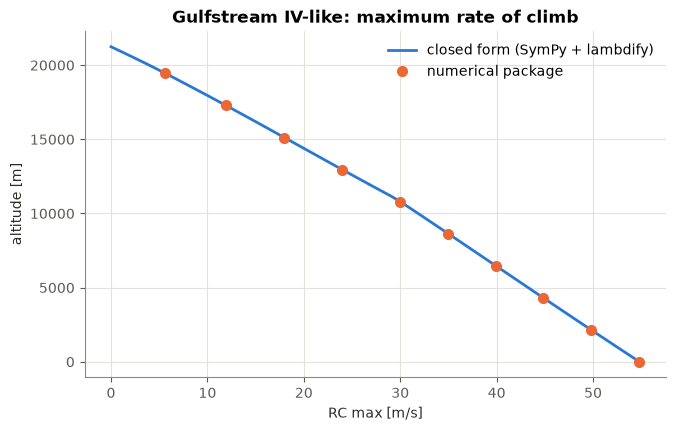


All symbolic results reproduced the reference values.


In [21]:
sigma_h = sigma_isa(hm)                                # Piecewise ISA density ratio
rc_of_h = sp.lambdify(hm, RC_jet_max.subs({T: T_SL * sigma_h**m_exp, rho: RHO0_ENGLISH * sigma_h})
                      .subs(giv).subs(S, 950) * FT, modules="numpy")
heights = np.linspace(0.0, float(h_abs_giv) - 1.0, 60)
rc_sym = np.array([rc_of_h(z) for z in heights])       # Piecewise -> evaluate point by point
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    rc_num = np.array([num_climb.max_rate_of_climb(examples.business_jet_giv(), z).rate for z in heights[::6]])

fig, ax = plt.subplots()
ax.plot(rc_sym, heights, label="closed form (SymPy + lambdify)")
ax.plot(rc_num, heights[::6], "o", label="numerical package")
ax.set_xlabel("RC max [m/s]")
ax.set_ylabel("altitude [m]")
ax.set_title("Gulfstream IV-like: maximum rate of climb")
ax.legend()
plt.show()

print("\nAll symbolic results reproduced the reference values.")

## 9. Exercises

1. Derive symbolically the speed of the steepest climb of a *propeller*
   aircraft ($\max[P/V - D(V)]$) and show that it is a root of a quartic in $V$.
2. Repeat Section 5.2 with $m = 1$: show that the absolute ceiling condition
   becomes $\sigma_{abs} = W/(E_{max}T_{SL})$ and compute it for the
   Gulfstream IV-like jet.
3. Use `sp.series` to expand $RC_{max}$ of the jet for small $C_{D_0}K$ and
   interpret the first two terms.